# Intro to text mining - Part 2 - Exercises

## Exercise 1

#### Task 1
##### Import the required packages.
##### Set the `data_dir` variable corresponding to your `data` folder
##### Print the `data_dir`

In [2]:
#=================================================-
#### Slide 6: Loading packages  ####

# Helper packages.
import pickle
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import nltk
import nltk.data
import numpy as np
import pandas as pd
import gensim
from gensim import corpora, models
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from wordcloud import WordCloud

In [3]:
data_dir = Path.cwd().parent / "data"

#### Result:

In [5]:
#=================================================-
#### Slide 9: Loading pickles  ####

out1 = data_dir / "titles_tokenized.pkl"
out2 = data_dir / "titles_word_count_list.pkl"
out3 = data_dir / "titles_clean.pkl"
out4 = data_dir / "titles_clean_list.pkl"
titles_tokenized = pickle.loads(out1.read_bytes())
word_counts_array = pickle.loads(out2.read_bytes())
processed_docs = pickle.loads(out3.read_bytes())
titles_clean_list = pickle.loads(out4.read_bytes())

#### Task 2
##### Load the pickle files which we pickled last time

#### Result:

#### Task 3
##### Create a `CountVectorizer()` and save it as `ex_vec`.
##### Create a DTM of the `titles_clean_list` and name it `ex_X`.
##### Convert `ex_X` to an array.
##### Print the  first 20 feature names of `ex_vec`.
##### Convert `ex_X` to a pandas dataframe `ex_DTM` and print the top 5 lines.

In [11]:
titles_clean_list = [s.replace('aagreement', 'agreement') for s in titles_clean_list]

In [13]:
#=================================================-
#### Slide 13: Create a DTM  ####

# Initialize `CountVectorizer`.
vec = CountVectorizer()

# Transform the list of snippets into DTM.
X = vec.fit_transform(titles_clean_list)
print(X.toarray()) #<- show output as a matrix

print(vec.get_feature_names_out()[:10])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['ababa' 'abolit' 'accommod' 'accord' 'account' 'accru' 'acquir'
 'acquisit' 'across' 'act']


#### Result:

In [14]:
#=================================================-
#### Slide 14: Create a DTM (cont'd)  ####

# Convert the matrix into a pandas dataframe for easier manipulation.
DTM = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print(DTM.head())

   ababa  abolit  accommod  accord  account  accru  acquir  acquisit  across  \
0      0       0         0       0        0      0       0         0       0   
1      0       0         0       0        0      0       0         0       0   
2      0       0         0       0        0      0       0         0       0   
3      0       0         0       0        0      0       0         0       0   
4      0       0         0       0        0      0       0         0       0   

   act  ...  yarnal  year  york  yosemit  young  youth  yugoslav  yugoslavia  \
0    0  ...       0     0     0        0      0      0         0           0   
1    0  ...       0     0     0        0      0      0         0           0   
2    0  ...       0     1     0        0      0      0         0           0   
3    0  ...       0     0     1        0      0      0         0           0   
4    0  ...       0     0     0        0      0      0         0           0   

   zealand  zone  
0        0     0  


#### Task 4
##### Use the convenience function that sorts and looks at first n-entries in the dictionary we defined in class.

#### Result:

In [15]:
#=================================================-
#### Slide 16: DTM to dictionary of total word counts (cont'd)  ####

# Create a convenience function that sorts and looks at first n-entries in the dictionary.
def sort_dict(dict_x, n=5, reverse=True):
    return dict(list(sorted(
        dict_x.items(), 
        reverse=reverse, 
        key=lambda kv: kv[1]
    ))[:n])

#### Task 5

#####  Sum the counts of each word in all documents and save the series as a dictionary `ex_corpus_freq_dist`.
##### Print the top 30 words and their counts in `ex_corpus_freq_dist`.

#### Result:

#### Task 6
##### Plot the frequency distribution of words in `ex_corpus_freq_dist` .

#### Result:

In [16]:
#=================================================-
#### Slide 17: DTM to dictionary of total word counts (cont'd)  ####

# Save series as a dictionary.
corpus_freq_dist = DTM.sum().to_dict()

# Glance at the frequencies.
print(sort_dict(corpus_freq_dist, 6))

{'agreement': 1120, 'exchang': 386, 'constitut': 334, 'note': 324, 'amend': 259, 'unit': 203}


#### Task 7
##### Create the word cloud of the entire corpus and name it `ex_wordcloud`.
##### Plot the wordcloud and set `figsize` to` (14, 7)`.

#### Result:

## Exercise 2

#### Task 1
##### Create a dictionary from `processed_docs_ex` object, using gensim's function.
##### Label the dictionary `dictionary_ex`.
##### Then loop through the dictionary printing out the first 10 items, key and value.
##### Make sure to set the seed as `2` for exercises.
##### Use `.filter_extremes()` to filter items. Set `keep_n` as `942`.

##### Result:

In [17]:
#=================================================-
#### Slide 50: Create a dictionary of counts   ####

# Set the seed.
np.random.seed(1)

dictionary = gensim.corpora.Dictionary(processed_docs)

# The loop below iterates through the first 10 items of the dictionary and prints out the key and value. 
count = 0
for k, v in dictionary.iteritems():
    print(k, v)
    count += 1
    if count > 10:
        break

0 administr
1 agreement
2 arrang
3 concern
4 conclud
5 council
6 de
7 fifth
8 geneva
9 hold
10 leagu


In [18]:
#=================================================-
#### Slide 51: Create a dictionary of counts   ####

dictionary.filter_extremes(no_below=5, no_above=0.5)

# How many words did are left in the dictionary?
len(dictionary)

286

#### Task 2
##### Write a list comprehension that transforms each doc within the `processed_docs_ex` .
##### Save this object, the output of the list comprehension, as `bow_corpus_ex`.
##### What type of object is this?

##### Result:

#### Task 3
##### Transform `bow_corpus_ex` to a TF-IDF transformed object using `TfIdfModel()`.
##### Preview the scores for the first document using `pprint`.

##### Result:

In [19]:
#=================================================-
#### Slide 52: Document to bag-of-words  ####

# We use a list comprehension to transform each doc within our processed_docs object.
bow_corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# Let's look at the first document.
print(bow_corpus[0])

[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 5), (7, 2), (8, 3)]


In [20]:
#=================================================-
#### Slide 56: Transform counts with TfidfModel  ####

# This is the transformation.
tfidf = models.TfidfModel(bow_corpus)

# Apply the transformation to the entire corpus.
corpus_tfidf = tfidf[bow_corpus]

# Preview TF-IDF scores for the first document.
pprint(corpus_tfidf[0])

[(0, 0.360987405543738),
 (1, 0.17608151222559473),
 (2, 0.06534628728773625),
 (3, 0.19810019048137678),
 (4, 0.15452818558002618),
 (5, 0.19810019048137678),
 (6, 0.7505799751687595),
 (7, 0.35216302445118947),
 (8, 0.21132399494080698)]


In [53]:
#=================================================-
#### Slide 58: Save results as a pickle  ####

pickle.dump(bow_corpus, open(str(data_dir) +'/bow_corpus.sav', 'wb'))
pickle.dump(corpus_tfidf, open(str(data_dir) + '/corpus_tfidf.sav', 'wb'))
pickle.dump(dictionary, open(str(data_dir) + '/dictionary.sav', 'wb'))
pickle.dump(DTM, open(str(data_dir) + '/DTM.sav', 'wb'))
pickle.dump(X, open(str(data_dir) + '/DTM_matrix.sav', 'wb'))

#### Task 4

##### Pickle the `ex_DTM` as `ex_DTM.sav`, `ex_X` as `ex_DTM_matrix.sav` 
##### `box_corpus_ex` as `box_corpus_ex.sav`, `corpus_tfidf_ex` as `corpus_tfidf_ex.sav` 
##### and `dictionary_ex` as `disctionary_ex.sav` for later use.

#### Result:

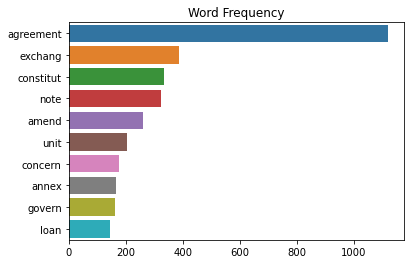

In [30]:
import seaborn as sns
cfd = pd.Series(sort_dict(corpus_freq_dist, n=10))
sns.barplot(x=cfd.values, y=cfd.index, orient='h')
plt.title('Word Frequency');

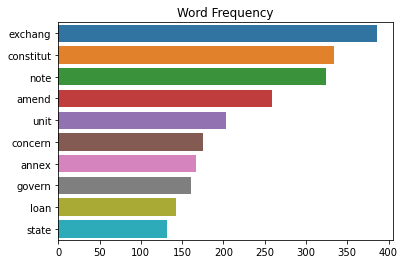

In [34]:
cfd = pd.Series(dict(dictionary.most_common(10)))
sns.barplot(x=cfd.values, y=cfd.index, orient='h')
plt.title('Word Frequency');